# **Evolució de les Temperatures Nocturnes a Sabadell**

Aquest notebook analitza l'evolució de les temperatures nocturnes i diürnes a les estacions de **Sabadell Nord** (dades horàries) i **Sabadell Centre** (dades diàries) al llarg dels anys.

**Definicions:**
- **Estiu:** 21 de juny → 21 de setembre (ambdós inclosos)
- **Nit (Sbd Nord):** 23:00h → 05:00h UTC (14 lectures de 30 min)
- **Night T_min:** temperatura mínima registrada durant la nit
- **Night T_max:** temperatura màxima registrada durant la nit
- **Dia (Sbd Centre / Sbd Nord diari):** T_min del dia complet

## 1. Càrrega i Preparació de Dades

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Carregar dades
df_nord = pd.read_csv('https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_nord_hourly.csv')
df_centre = pd.read_csv('https://raw.githubusercontent.com/DavidDDRC99/VO-evolution/refs/heads/main/Cleaned%20Data/Sbd_Centre_daily.csv')

# Parse datetime
df_nord['datetime_utc'] = pd.to_datetime(df_nord['datetime_utc'])
df_centre['date'] = pd.to_datetime(df_centre['date'])

# Extreure components (vectoritzat)
df_nord['hour'] = df_nord['datetime_utc'].dt.hour
df_nord['month'] = df_nord['datetime_utc'].dt.month
df_nord['day'] = df_nord['datetime_utc'].dt.day
df_nord['year'] = df_nord['datetime_utc'].dt.year

df_centre['month'] = df_centre['date'].dt.month
df_centre['day'] = df_centre['date'].dt.day
df_centre['year'] = df_centre['date'].dt.year

print(f"Sbd Nord:  {len(df_nord)} registres | {df_nord['datetime_utc'].min().date()} → {df_nord['datetime_utc'].max().date()}")
print(f"Sbd Centre: {len(df_centre)} registres | {df_centre['date'].min().date()} → {df_centre['date'].max().date()}")

Sbd Nord:  305664 registres | 2008-10-24 → 2026-04-01
Sbd Centre: 5834 registres | 2008-05-06 → 2026-01-31


## 2. Filtres Vectoritzats: Estiu + Nit

In [2]:
# === FILTRE ESTIVAL VECTORITZAT: 21 juny → 21 setembre ===
def summer_mask(month, day):
    return (
        ((month == 6) & (day >= 21)) |
        (month.isin([7, 8])) |
        ((month == 9) & (day <= 21))
    )

# === FILTRE NOCTURN VECTORITZAT: 23:00 → 05:00 (14 lectures) ===
def night_mask(hour):
    return (hour >= 23) | (hour <= 5)

# === ASSIGNAR DATA DE LA NIT (vectoritzat) ===
# Les lectures de 00:00-05:30 pertanyen a la nit del dia anterior
# La nit del 21 de setembre inclou lectures del 22 de setembre (00:00-05:00)
df_nord['night_date'] = df_nord['datetime_utc'].dt.normalize()
early_mask = df_nord['hour'] <= 5
df_nord.loc[early_mask, 'night_date'] -= pd.Timedelta(days=1)

# Aplicar filtres
df_nord['is_summer'] = summer_mask(df_nord['month'], df_nord['day'])
df_nord['is_night'] = night_mask(df_nord['hour'])

# Per la nit del 21 de setembre, necessitem incloure lectures del 22 set
# que són part de la mateixa nit. Primer filtre per nit, després per summer night_date.
df_night_only = df_nord[df_nord['is_night']].copy()
df_night_only['night_month'] = df_night_only['night_date'].dt.month
df_night_only['night_day'] = df_night_only['night_date'].dt.day
df_night_only['is_summer_night'] = summer_mask(df_night_only['night_month'], df_night_only['night_day'])

df_summer_night = df_night_only[df_night_only['is_summer_night']].copy()

# També filtrar Sbd Centre per estiu
df_centre['is_summer'] = summer_mask(df_centre['month'], df_centre['day'])
df_centre_summer = df_centre[df_centre['is_summer']].copy()

print(f"Registres nocturns d'estiu (Sbd Nord): {len(df_summer_night)}")
print(f"Nits úniques: {df_summer_night['night_date'].nunique()}")
print(f"Dies d'estiu (Sbd Centre): {len(df_centre_summer)}")

Registres nocturns d'estiu (Sbd Nord): 22134
Nits úniques: 1581
Dies d'estiu (Sbd Centre): 1421


## 3. Agregació per Nit (Sbd Nord) i per Dia (Sbd Centre)

In [3]:
# === SBD NORD: agregació per nit ===
nights = df_summer_night.groupby('night_date').agg(
    night_T_min=('T_min', 'min'),
    night_T_max=('T_max', 'max'),
    readings_count=('T_avg', 'count'),
    year=('year', 'first'),
).reset_index()

# 14 lectures esperades per nit (23:00, 23:30, 00:00, ..., 05:00, 05:30)
EXPECTED_READINGS = 14
nights['is_complete'] = nights['readings_count'] >= 11  # >= 78%
nights = nights.dropna(subset=['night_T_min', 'night_T_max'])

# === SBD CENTRE: ja és diari, només cal extreure T_min ===
daily_centre = df_centre_summer[['date', 'year', 'T_min', 'T_max']].copy()
daily_centre = daily_centre.dropna(subset=['T_min'])

print(f"Nits Sbd Nord (completes): {nights['is_complete'].sum()} / {len(nights)}")
print(f"Dies Sbd Centre (vàlids): {len(daily_centre)}")

Nits Sbd Nord (completes): 1581 / 1581
Dies Sbd Centre (vàlids): 1421


## 4. Comprovació de Cobertura

In [4]:
EXPECTED_SUMMER_DAYS = 93  # 21 jun → 21 set

# Cobertura Sbd Nord
cov_nord = nights.groupby('year').agg(
    total=('night_date', 'count'),
    complete=('is_complete', 'sum'),
).reset_index()
cov_nord['pct'] = cov_nord['complete'] / EXPECTED_SUMMER_DAYS
cov_nord['station'] = 'Sbd Nord'

# Cobertura Sbd Centre
cov_centre = daily_centre.groupby('year').agg(
    total=('date', 'count'),
).reset_index()
cov_centre['complete'] = cov_centre['total']
cov_centre['pct'] = cov_centre['complete'] / EXPECTED_SUMMER_DAYS
cov_centre['station'] = 'Sbd Centre'

valid_years_nord = cov_nord[cov_nord['pct'] >= 0.70]['year'].tolist()
valid_years_centre = cov_centre[cov_centre['pct'] >= 0.70]['year'].tolist()

print(f"Anys vàlids Sbd Nord:  {sorted(valid_years_nord)}")
print(f"Anys vàlids Sbd Centre: {sorted(valid_years_centre)}")

Anys vàlids Sbd Nord:  [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Anys vàlids Sbd Centre: [2009, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


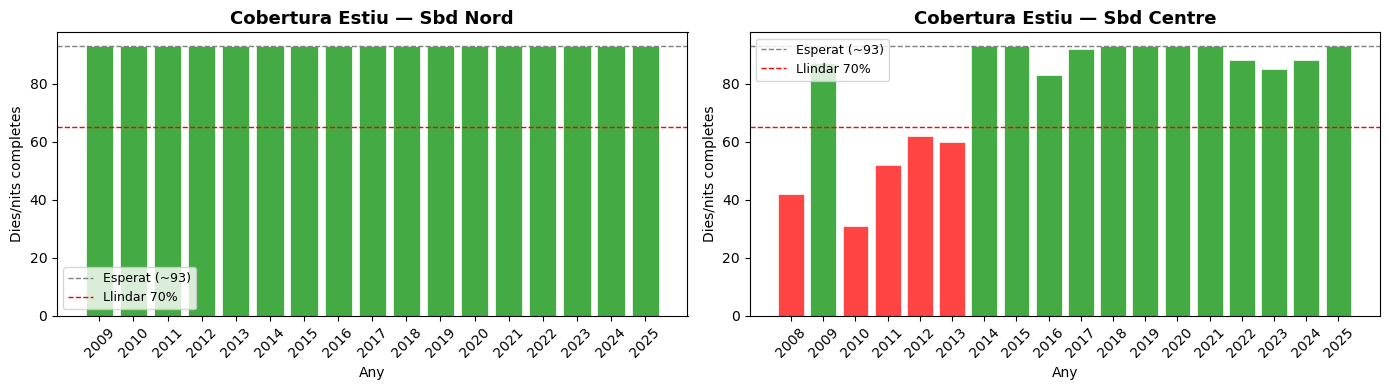

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, cov, name in [(axes[0], cov_nord, 'Sbd Nord'), (axes[1], cov_centre, 'Sbd Centre')]:
    colors = ['#44aa44' if p >= 0.70 else '#ff4444' for p in cov['pct']]
    ax.bar(cov['year'], cov['complete'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(EXPECTED_SUMMER_DAYS, color='gray', linestyle='--', linewidth=1, label=f'Esperat (~{EXPECTED_SUMMER_DAYS})')
    ax.axhline(0.70 * EXPECTED_SUMMER_DAYS, color='red', linestyle='--', linewidth=1, label='Llindar 70%')
    ax.set_title(f'Cobertura Estiu — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Any')
    ax.set_ylabel('Dies/nits completes')
    ax.legend(fontsize=9)
    ax.set_xticks(cov['year'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# Filtrar a dades vàlides
nights_valid = nights[nights['is_complete'] & nights['year'].isin(valid_years_nord)].copy()
daily_centre_valid = daily_centre[daily_centre['year'].isin(valid_years_centre)].copy()

print(f"Nits vàlides Sbd Nord:  {len(nights_valid)}")
print(f"Dies vàlids Sbd Centre: {len(daily_centre_valid)}")

Nits vàlides Sbd Nord:  1581
Dies vàlids Sbd Centre: 1174


## 5. Funcions Reutilitzables

In [6]:
def count_above_threshold(data, col, threshold):
    """Comptar per any quants valors superen un llindar."""
    yearly = data.groupby('year').apply(
        lambda g: (g[col] > threshold).sum()
    ).reset_index()
    yearly.columns = ['year', 'count']
    return yearly


def compute_streaks(data, col, threshold):
    """
    Per cada any, computa:
    - longest_streak: racó màxim de dies/nits consecutius amb temp > threshold
    - n_streaks_3plus: nombre de ratxes de >= 3 dies
    """
    results = []
    for year, group in data.groupby('year'):
        group = group.sort_values('night_date' if 'night_date' in group.columns else 'date')
        above = (group[col] > threshold).astype(int).values
        
        if len(above) == 0:
            results.append({'year': year, 'longest_streak': 0, 'n_streaks_3plus': 0})
            continue
        
        # Trobar ratxes consecutives
        longest = 0
        current = 0
        streaks_3plus = 0
        
        for val in above:
            if val == 1:
                current += 1
            else:
                if current >= 3:
                    streaks_3plus += 1
                longest = max(longest, current)
                current = 0
        # Última ratxa
        if current >= 3:
            streaks_3plus += 1
        longest = max(longest, current)
        
        results.append({'year': year, 'longest_streak': longest, 'n_streaks_3plus': streaks_3plus})
    
    return pd.DataFrame(results)


def add_trend_line(ax, years, values, color='red', label=None):
    """Afegeix una línia de tendència linear a un plot."""
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    if len(years) >= 3:
        slope, intercept, r_val, p_val, _ = stats.linregress(years, values)
        lbl = label or f'Tendència: {slope:+.2f}/any'
        ax.plot(years, intercept + slope * years, color=color, linestyle='--',
                linewidth=2, label=lbl)
        return slope, r_val**2, p_val
    return None, None, None

## 6. Nits Càlides — Barres per Llindar (Sbd Nord)

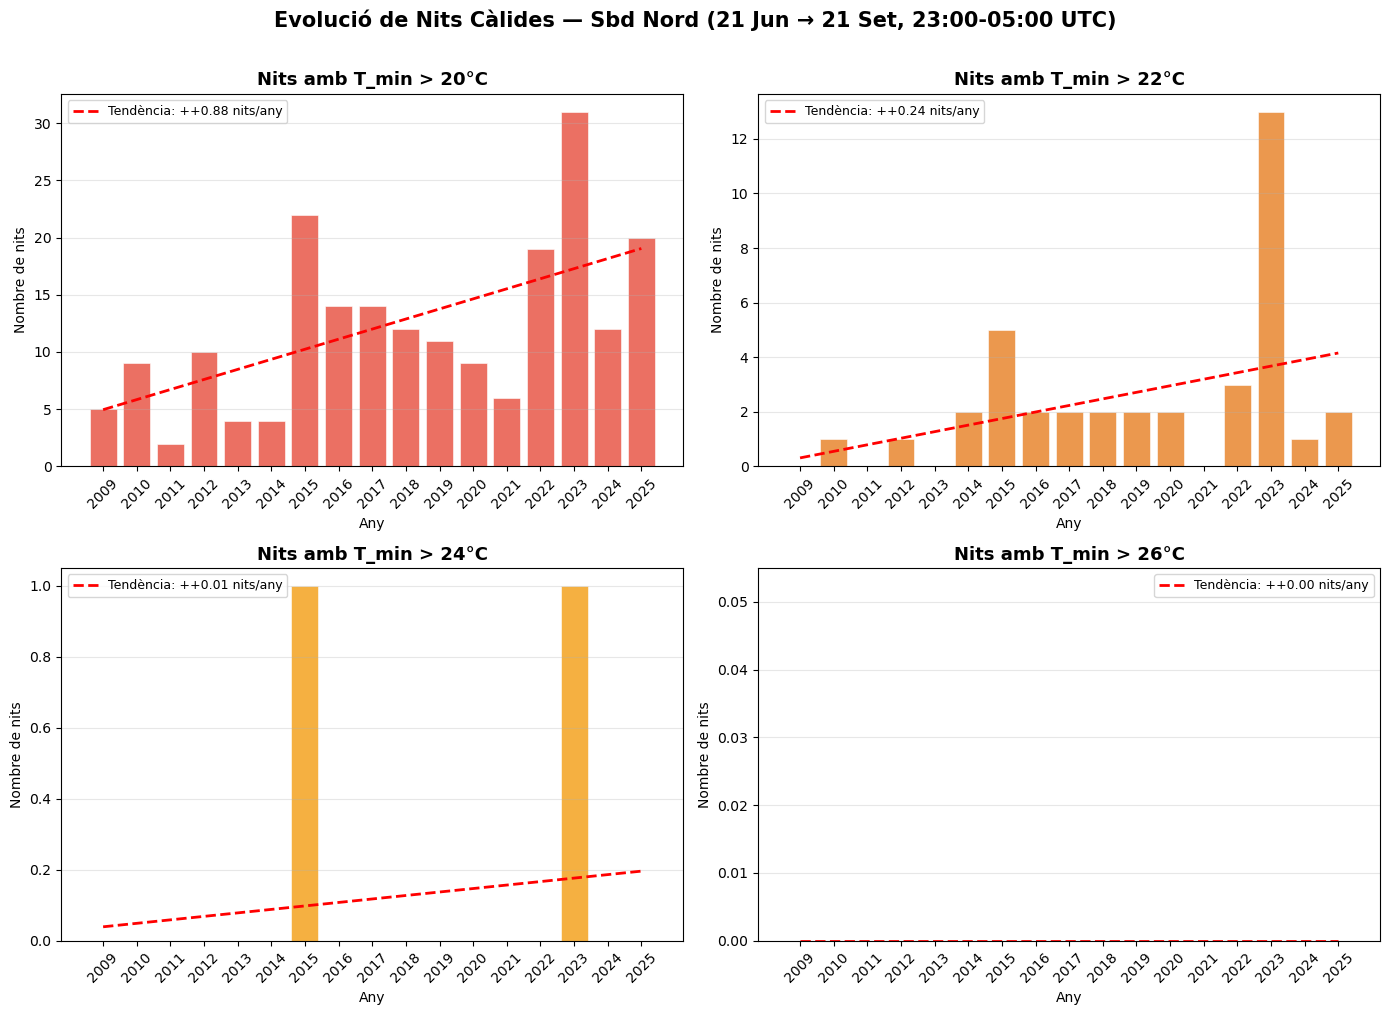

In [7]:
def plot_threshold_bars(data, col, threshold, ax, color):
    yearly = count_above_threshold(data, col, threshold)
    years = yearly['year'].values
    counts = yearly['count'].values
    
    ax.bar(years, counts, color=color, edgecolor='white', linewidth=0.5, alpha=0.8)
    add_trend_line(ax, years, counts, color='red', label=f'Tendència: +{stats.linregress(years, counts)[0]:+.2f} nits/any')
    
    ax.set_title(f'Nits amb T_min > {threshold}°C', fontsize=13, fontweight='bold')
    ax.set_xlabel('Any')
    ax.set_ylabel('Nombre de nits')
    ax.legend(fontsize=9)
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

thresholds = [20, 22, 24, 26]
colors = ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f']

for ax, thresh, col in zip(axes, thresholds, colors):
    plot_threshold_bars(nights_valid, 'night_T_min', thresh, ax, col)

fig.suptitle('Evolució de Nits Càlides — Sbd Nord (21 Jun → 21 Set, 23:00-05:00 UTC)',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

## 7. Gràfic Sobreposat + Percentils (Sbd Nord)

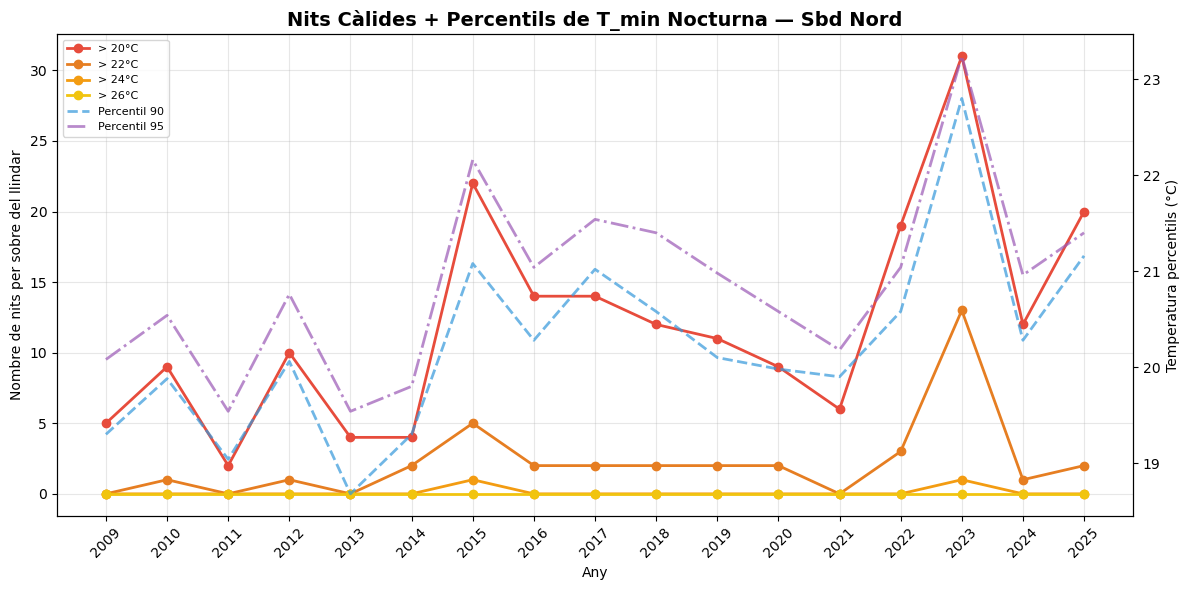

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

thresholds = [20, 22, 24, 26]
line_colors = ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f']

# Eix esquerre
for thresh, color in zip(thresholds, line_colors):
    yearly = count_above_threshold(nights_valid, 'night_T_min', thresh)

    ax.plot(
        yearly['year'],
        yearly['count'],
        marker='o',
        linewidth=2,
        color=color,
        label=f'> {thresh}°C',
        markersize=6
    )

# Crear UN sol eix dret
ax2 = ax.twinx()

# Percentils
for p, style, pcolor in [(90, '--', '#3498db'),
                         (95, '-.', '#9b59b6')]:

    p_vals = nights_valid.groupby('year')['night_T_min'].apply(
        lambda x: np.percentile(x.dropna(), p)
    )

    ax2.plot(
        p_vals.index,
        p_vals.values,
        linestyle=style,
        color=pcolor,
        linewidth=2,
        label=f'Percentil {p}',
        alpha=0.7
    )

ax.set_title(
    'Nits Càlides + Percentils de T_min Nocturna — Sbd Nord',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Any')
ax.set_ylabel('Nombre de nits per sobre del llindar')

ax2.set_ylabel('Temperatura percentils (°C)')

ax.set_xticks(sorted(nights_valid['year'].unique()))
ax.tick_params(axis='x', rotation=45)

ax.grid(alpha=0.3)

# Combinar llegendes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    fontsize=8
)

plt.tight_layout()
plt.show()

## 8. Ratxes Consecutives de Nits Càlides (Sbd Nord)

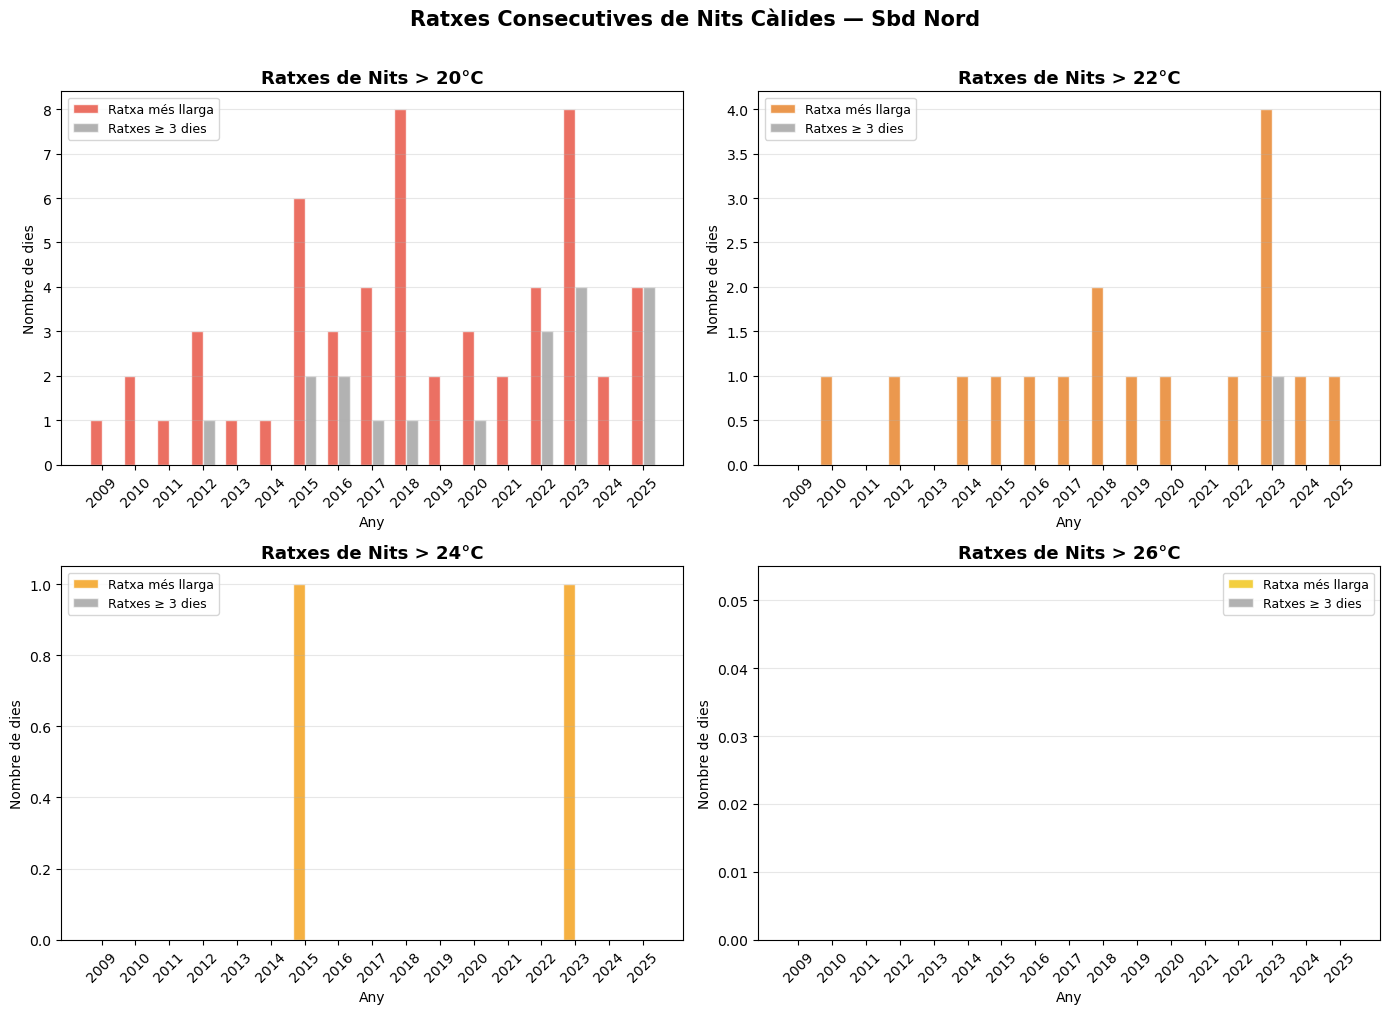

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, thresh, color in zip(axes, [20, 22, 24, 26], ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f']):
    streaks = compute_streaks(nights_valid, 'night_T_min', thresh)
    years = streaks['year'].values
    
    width = 0.35
    x = np.arange(len(years))
    
    bars1 = ax.bar(x - width/2, streaks['longest_streak'], width, label='Ratxa més llarga',
                   color=color, alpha=0.8, edgecolor='white')
    bars2 = ax.bar(x + width/2, streaks['n_streaks_3plus'], width, label='Ratxes ≥ 3 dies',
                   color='gray', alpha=0.6, edgecolor='white')
    
    ax.set_title(f'Ratxes de Nits > {thresh}°C', fontsize=13, fontweight='bold')
    ax.set_xlabel('Any')
    ax.set_ylabel('Nombre de dies')
    ax.set_xticks(x)
    ax.set_xticklabels([str(y) for y in years], rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Ratxes Consecutives de Nits Càlides — Sbd Nord', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Boxplots — T_max Nocturna per Any (Sbd Nord)

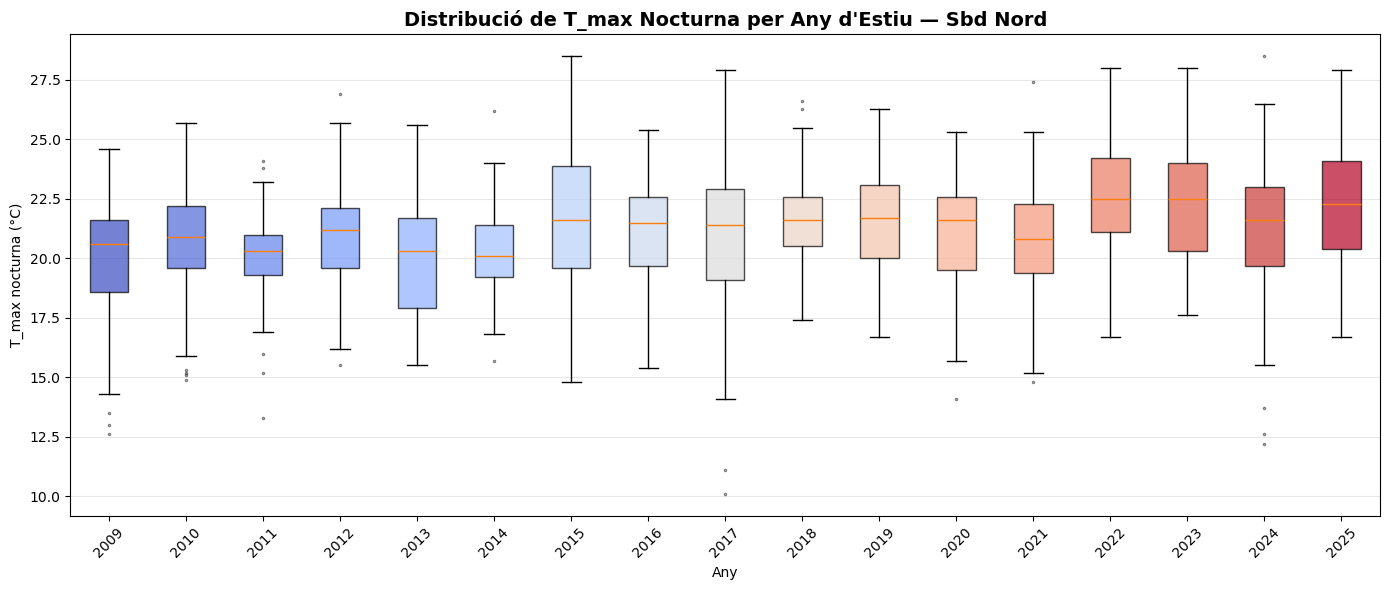

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

years_sorted = sorted(nights_valid['year'].unique())

box_data = [
    nights_valid[nights_valid['year'] == y]['night_T_max']
    .dropna()
    .values
    for y in years_sorted
]

bp = ax.boxplot(
    box_data,
    labels=[str(y) for y in years_sorted],
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker='.', markersize=3, alpha=0.5)
)

# Color gradient per any
norm = plt.Normalize(min(years_sorted), max(years_sorted))
cmap = plt.cm.coolwarm

for patch, year in zip(bp['boxes'], years_sorted):
    patch.set_facecolor(cmap(norm(year)))
    patch.set_alpha(0.7)

ax.set_title(
    'Distribució de T_max Nocturna per Any d\'Estiu — Sbd Nord',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Any')
ax.set_ylabel('T_max nocturna (°C)')

ax.set_xticklabels([str(y) for y in years_sorted], rotation=45)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Comparació Diària — Sbd Nord vs Sbd Centre

Com que Sbd Centre només té dades diàries, comparem la **T_min diària** de les dues estacions. Per a Sbd Nord, agafem la T_min del dia complet (no només la nit).

In [11]:
# Preparar dades diàries de Sbd Nord per comparar
df_nord['is_summer_daily'] = summer_mask(df_nord['month'], df_nord['day'])
df_nord_summer = df_nord[df_nord['is_summer_daily']].copy()

daily_nord = df_nord_summer.groupby(df_nord_summer['datetime_utc'].dt.date).agg(
    T_min=('T_min', 'min'),
    T_max=('T_max', 'max'),
    year=('year', 'first'),
).reset_index()
daily_nord.rename(columns={'datetime_utc': 'date'}, inplace=True)
daily_nord['date'] = pd.to_datetime(daily_nord['date'])
daily_nord = daily_nord.dropna(subset=['T_min'])
daily_nord_valid = daily_nord[daily_nord['year'].isin(valid_years_nord)].copy()

print(f"Dies d'estiu Sbd Nord (diari): {len(daily_nord_valid)}")
print(f"Dies d'estiu Sbd Centre (diari): {len(daily_centre_valid)}")

Dies d'estiu Sbd Nord (diari): 1581
Dies d'estiu Sbd Centre (diari): 1174


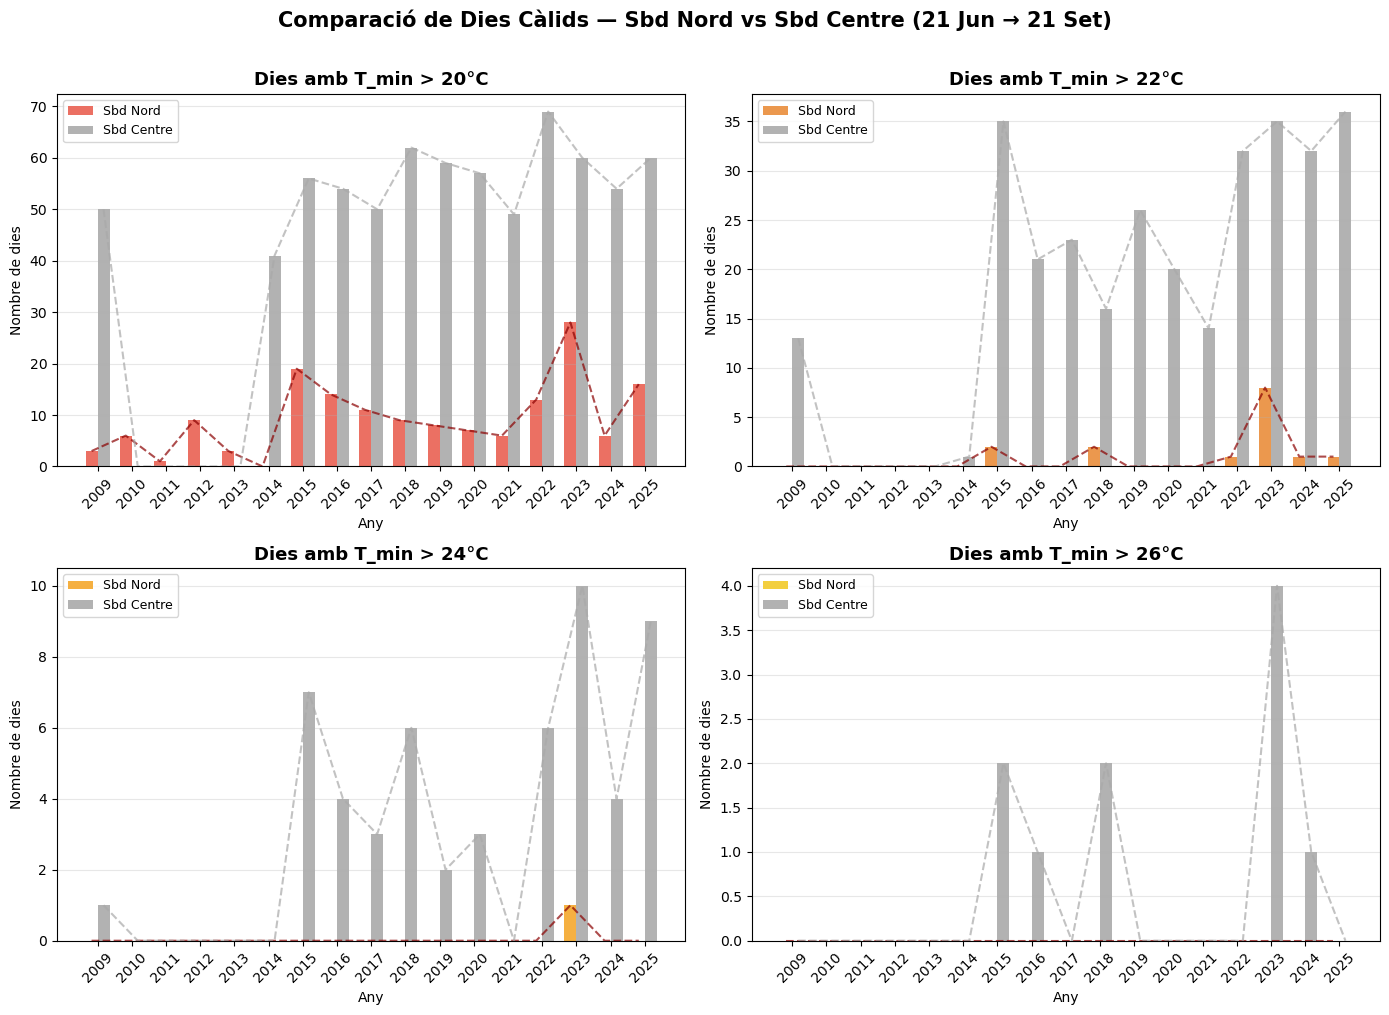

In [16]:
# Barres comparatives per llindar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, thresh, color in zip(axes, [20, 22, 24, 26], ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f']):
    y_nord = count_above_threshold(daily_nord_valid, 'T_min', thresh)
    y_centre = count_above_threshold(daily_centre_valid, 'T_min', thresh)
    
    # Merge per tenir els mateixos anys
    merged = pd.merge(y_nord, y_centre, on='year', suffixes=('_nord', '_centre'), how='outer').fillna(0)
    merged = merged.sort_values('year')
    
    width = 0.35
    x = np.arange(len(merged['year']))
    
    ax.bar(x - width/2, merged['count_nord'], width, label='Sbd Nord', color=color, alpha=0.8)
    ax.bar(x + width/2, merged['count_centre'], width, label='Sbd Centre', color='gray', alpha=0.6)
    
    # Tendència per Sbd Nord
    if len(merged) >= 3:
        s_n, _, _, _, _ = stats.linregress(merged['year'].values, merged['count_nord'].values)
        s_c, _, _, _, _ = stats.linregress(merged['year'].values, merged['count_centre'].values)
        ax.plot(x - width/2, merged['count_nord'].values,
                color='darkred', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.plot(x + width/2, merged['count_centre'].values,
                color='darkgray', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_title(f'Dies amb T_min > {thresh}°C', fontsize=13, fontweight='bold')
    ax.set_xlabel('Any')
    ax.set_ylabel('Nombre de dies')
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(y)) for y in merged['year']], rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Comparació de Dies Càlids — Sbd Nord vs Sbd Centre (21 Jun → 21 Set)',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

## 11. Ratxes Consecutives — Comparació Sbd Nord vs Sbd Centre

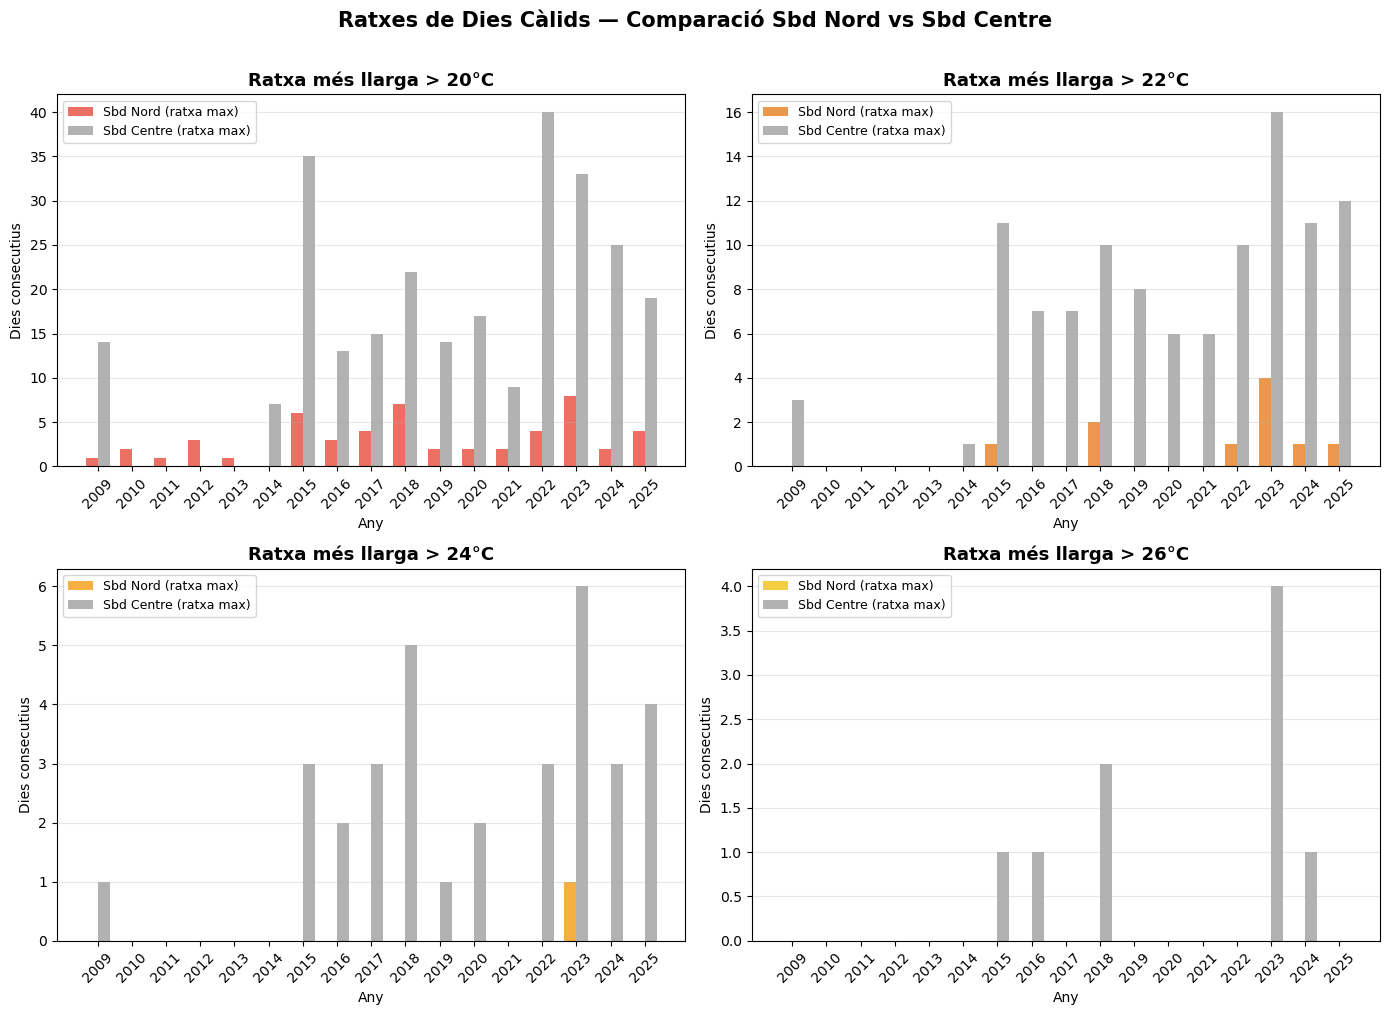

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, thresh, color in zip(axes, [20, 22, 24, 26], ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f']):
    s_nord = compute_streaks(daily_nord_valid, 'T_min', thresh)
    s_centre = compute_streaks(daily_centre_valid, 'T_min', thresh)
    
    merged_s = pd.merge(s_nord, s_centre, on='year', suffixes=('_nord', '_centre'), how='outer').fillna(0)
    merged_s = merged_s.sort_values('year')
    
    width = 0.35
    x = np.arange(len(merged_s['year']))
    
    ax.bar(x - width/2, merged_s['longest_streak_nord'], width, label='Sbd Nord (ratxa max)',
           color=color, alpha=0.8)
    ax.bar(x + width/2, merged_s['longest_streak_centre'], width, label='Sbd Centre (ratxa max)',
           color='gray', alpha=0.6)
    
    ax.set_title(f'Ratxa més llarga > {thresh}°C', fontsize=13, fontweight='bold')
    ax.set_xlabel('Any')
    ax.set_ylabel('Dies consecutius')
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(y)) for y in merged_s['year']], rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Ratxes de Dies Càlids — Comparació Sbd Nord vs Sbd Centre',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

## 12. Boxplots Comparatius — T_min Diària

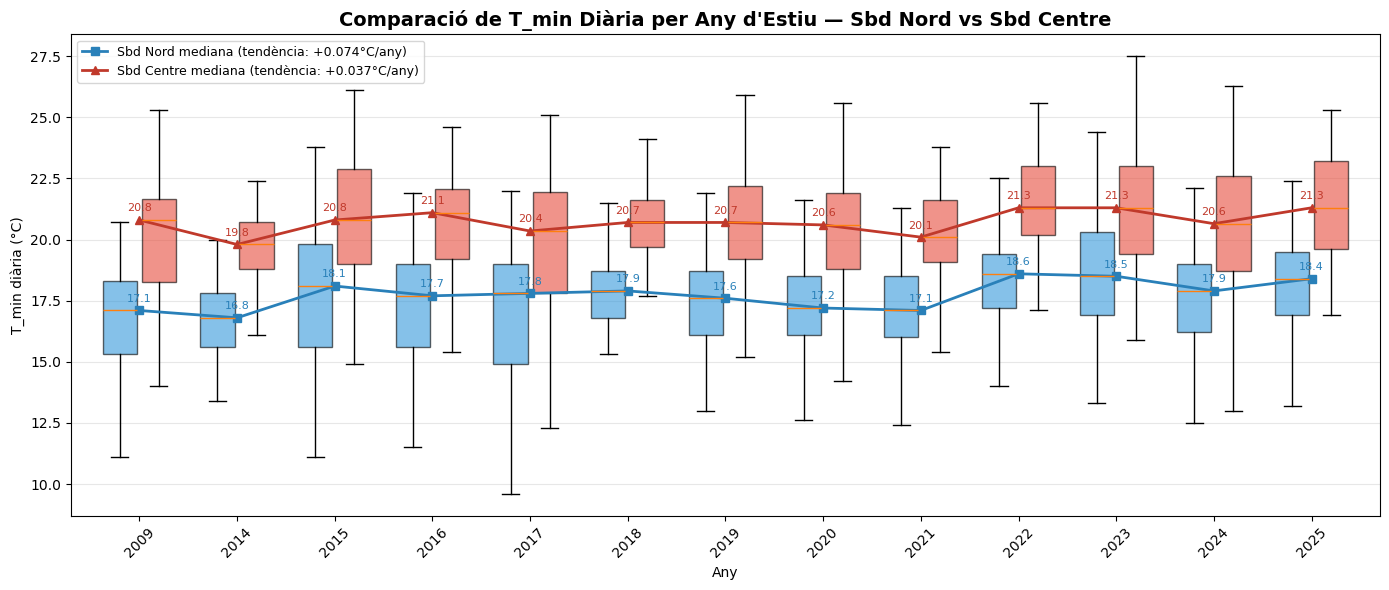

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

years_common = sorted(set(valid_years_nord) & set(valid_years_centre))

box_nord = [daily_nord_valid[daily_nord_valid['year'] == y]['T_min'].dropna().values for y in years_common]
box_centre = [daily_centre_valid[daily_centre_valid['year'] == y]['T_min'].dropna().values for y in years_common]

# Boxplots Sbd Nord
bp_nord = ax.boxplot(box_nord, positions=np.arange(len(years_common)) - 0.2,
                     widths=0.35, patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#3498db', alpha=0.6))

# Boxplots Sbd Centre
bp_centre = ax.boxplot(box_centre, positions=np.arange(len(years_common)) + 0.2,
                       widths=0.35, patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor='#e74c3c', alpha=0.6))

# Línies de tendència de medianes
med_nord = [np.median(d) for d in box_nord]
med_centre = [np.median(d) for d in box_centre]

ax.plot(np.arange(len(years_common)), med_nord, color='#2980b9', marker='s', linewidth=2,
        label=f'Sbd Nord mediana (tendència: {stats.linregress(years_common, med_nord)[0]:+.3f}°C/any)')
ax.plot(np.arange(len(years_common)), med_centre, color='#c0392b', marker='^', linewidth=2,
        label=f'Sbd Centre mediana (tendència: {stats.linregress(years_common, med_centre)[0]:+.3f}°C/any)')

# Mostrar valors sobre els punts Sbd Nord
for i, val in enumerate(med_nord):
    ax.text(
        i,
        val + 0.35,
        f'{val:.1f}',
        color='#2980b9',
        fontsize=8,
        ha='center'
    )

# Mostrar valors sobre els punts Sbd Centre
for i, val in enumerate(med_centre):
    ax.text(
        i,
        val + 0.35,
        f'{val:.1f}',
        color='#c0392b',
        fontsize=8,
        ha='center'
    )

ax.set_title('Comparació de T_min Diària per Any d\'Estiu — Sbd Nord vs Sbd Centre', fontsize=14, fontweight='bold')
ax.set_xlabel('Any')
ax.set_ylabel('T_min diària (°C)')
ax.set_xticks(np.arange(len(years_common)))
ax.set_xticklabels([str(y) for y in years_common], rotation=45)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Taula Resum i Conclusions

In [14]:
# Resum Sbd Nord (nocturn)
summary_nord = nights_valid.groupby('year').agg(
    nits=('night_date', 'count'),
    T_min_med=('night_T_min', 'median'),
    T_max_med=('night_T_max', 'median'),
).reset_index()

for thresh in [20, 22, 24, 26]:
    summary_nord[f'>{thresh}'] = nights_valid.groupby('year').apply(
        lambda g: (g['night_T_min'] > thresh).sum()
    ).values

# Resum Sbd Centre (diari)
summary_centre = daily_centre_valid.groupby('year').agg(
    dies=('date', 'count'),
    T_min_med=('T_min', 'median'),
).reset_index()

for thresh in [20, 22, 24, 26]:
    summary_centre[f'>{thresh}'] = daily_centre_valid.groupby('year').apply(
        lambda g: (g['T_min'] > thresh).sum()
    ).values

print("=" * 80)
print("  SBD NORD — Resum Nocturn (23:00-05:00 UTC)")
print("=" * 80)
print(f"{'Any':<6} {'Nits':<6} {'T_min med':<10} {'T_max med':<10} {'>20':<6} {'>22':<6} {'>24':<6} {'>26':<6}")
print("-" * 70)
for _, row in summary_nord.iterrows():
    print(f"{int(row['year']):<6} {int(row['nits']):<6} {row['T_min_med']:<10.1f} {row['T_max_med']:<10.1f} "
          f"{int(row['>20']):<6} {int(row['>22']):<6} {int(row['>24']):<6} {int(row['>26']):<6}")

print("\n" + "=" * 80)
print("  SBD CENTRE — Resum Diari")
print("=" * 80)
print(f"{'Any':<6} {'Dies':<6} {'T_min med':<10} {'>20':<6} {'>22':<6} {'>24':<6} {'>26':<6}")
print("-" * 55)
for _, row in summary_centre.iterrows():
    print(f"{int(row['year']):<6} {int(row['dies']):<6} {row['T_min_med']:<10.1f} "
          f"{int(row['>20']):<6} {int(row['>22']):<6} {int(row['>24']):<6} {int(row['>26']):<6}")

  SBD NORD — Resum Nocturn (23:00-05:00 UTC)
Any    Nits   T_min med  T_max med  >20    >22    >24    >26   
----------------------------------------------------------------------
2009   93     17.5       20.6       5      0      0      0     
2010   93     17.8       20.9       9      1      0      0     
2011   93     16.8       20.3       2      0      0      0     
2012   93     17.2       21.2       10     1      0      0     
2013   93     16.5       20.3       4      0      0      0     
2014   93     16.9       20.1       4      2      0      0     
2015   93     18.6       21.6       22     5      1      0     
2016   93     17.8       21.5       14     2      0      0     
2017   93     17.9       21.4       14     2      0      0     
2018   93     18.2       21.6       12     2      0      0     
2019   93     17.8       21.7       11     2      0      0     
2020   93     17.3       21.6       9      2      0      0     
2021   93     17.2       20.8       6      0      0 

In [20]:
print("="*70)
print("  RESUM FINAL — EVOLUCIÓ DE TEMPERATURES D\'ESTIU")
print("="*70)

# Sbd Nord — nocturn
print("\n  [Sbd Nord] Nits càlides (23:00-05:00 UTC):")
for thresh in [20, 22, 24, 26]:
    years_arr = summary_nord['year'].values
    counts = summary_nord[f'>{thresh}'].values
    slope, r2, p = stats.linregress(years_arr, counts)[:3]
    r2 = r2
    sig = '✓' if p < 0.05 else '✗'
    print(f"    > {thresh}°C: {slope:+.2f} nits/any  (R²={r2:.3f}, p={p:.4f}) {sig}")

# Ratxes
for thresh in [20, 22]:
    streaks = compute_streaks(nights_valid, 'night_T_min', thresh)
    slope_s, _, p_s = stats.linregress(streaks['year'].values, streaks['longest_streak'].values)[:3]
    sig_s = '✓' if p_s < 0.05 else '✗'
    print(f"    Ratxa max > {thresh}°C: {slope_s:+.2f} dies/any  (p={p_s:.4f}) {sig_s}")

# Sbd Nord — diari
print("\n  [Sbd Nord] Dies càlids (T_min diària):")
for thresh in [20, 22, 24, 26]:
    years_arr = summary_nord['year'].values
    counts = summary_nord[f'>{thresh}'].values
    slope, r2, p = stats.linregress(years_arr, counts)[:3]
    sig = '✓' if p < 0.05 else '✗'
    print(f"    > {thresh}°C: {slope:+.2f} dies/any  (R²={r2:.3f}, p={p:.4f}) {sig}")

# Sbd Centre — diari
print("\n  [Sbd Centre] Dies càlids (T_min diària):")
for thresh in [20, 22, 24, 26]:
    years_arr = summary_centre['year'].values
    counts = summary_centre[f'>{thresh}'].values
    slope, r2, p = stats.linregress(years_arr, counts)[:3]
    sig = '✓' if p < 0.05 else '✗'
    print(f"    > {thresh}°C: {slope:+.2f} dies/any  (R²={r2:.3f}, p={p:.4f}) {sig}")

print("\n" + "="*70)
print("  NOTA: Les hores són UTC. 23:00-05:00 UTC = 01:00-07:00 hora local estiu.")
print("  Les nits tropicals (T_min > 20°C) estan marcades segons definició OMM.")
print("="*70)

  RESUM FINAL — EVOLUCIÓ DE TEMPERATURES D'ESTIU

  [Sbd Nord] Nits càlides (23:00-05:00 UTC):
    > 20°C: +0.88 nits/any  (R²=-1762.762, p=0.5866) ✗
    > 22°C: +0.24 nits/any  (R²=-482.240, p=0.3974) ✗
    > 24°C: +0.01 nits/any  (R²=-19.657, p=0.1491) ✗
    > 26°C: +0.00 nits/any  (R²=0.000, p=0.0000) ✓
    Ratxa max > 20°C: +0.19 dies/any  (p=0.4289) ✗
    Ratxa max > 22°C: +0.08 dies/any  (p=0.4366) ✗

  [Sbd Nord] Dies càlids (T_min diària):
    > 20°C: +0.88 dies/any  (R²=-1762.762, p=0.5866) ✗
    > 22°C: +0.24 dies/any  (R²=-482.240, p=0.3974) ✗
    > 24°C: +0.01 dies/any  (R²=-19.657, p=0.1491) ✗
    > 26°C: +0.00 dies/any  (R²=0.000, p=0.0000) ✓

  [Sbd Centre] Dies càlids (T_min diària):
    > 20°C: +0.82 dies/any  (R²=-1600.983, p=0.5253) ✗
    > 22°C: +1.44 dies/any  (R²=-2892.363, p=0.6143) ✗
    > 24°C: +0.37 dies/any  (R²=-737.394, p=0.5155) ✗
    > 26°C: +0.05 dies/any  (R²=-90.586, p=0.1655) ✗

  NOTA: Les hores són UTC. 23:00-05:00 UTC = 01:00-07:00 hora local estiu

In [15]:
# === Statistical trend analysis ===
import sys
sys.path.insert(0, r"C:\Users\David\Documents\VO project\VO-evolution\scripts")
from statistical_tests import (
    mk_analysis_series, mann_kendall, sens_slope, pettitt_test,
    seasonal_mann_kendall, print_mk_table
)
from scipy import stats
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


## 14. Trend Analysis — Statistical Tests

Mann-Kendall trend tests on nighttime summer temperature metrics.

### 14.1 Trend in Nighttime T_min (mean per year)

In [16]:
# MK on mean T_min per year (summer nights, Sbd Nord)
nightly_mean = nights_valid.groupby('year')['night_T_min'].mean().reset_index()
r_nord = mk_analysis_series(
    nightly_mean['year'].values, nightly_mean['night_T_min'].values,
    'Mean night T_min — Sbd Nord'
)
print(f"\n{r_nord['summary']}")

# Sbd Centre daily T_min for comparison
daily_mean = daily_centre_valid.groupby('year')['T_min'].mean().reset_index()
r_centre = mk_analysis_series(
    daily_mean['year'].values, daily_mean['T_min'].values,
    'Mean T_min — Sbd Centre'
)
print(f"\n{r_centre['summary']}")



--- Mean night T_min — Sbd Nord ---
  Mann-Kendall tau = 0.5588, p = 0.0013 (increasing)
  Sen's slope = 0.0876 per year [0.0305, 0.1535]
  Pettitt change point: index=6, year~2015, p=0.4562 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 YES

--- Mean T_min — Sbd Centre ---
  Mann-Kendall tau = 0.3077, p = 0.1635 (no trend)
  Sen's slope = 0.0761 per year [-0.0391, 0.1697]
  Pettitt change point: index=9, year~2022, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no


### 14.2 Trend in Nighttime T_max (mean per year)

In [17]:
nightly_tmax = nights_valid.groupby('year')['night_T_max'].mean().reset_index()
r = mk_analysis_series(
    nightly_tmax['year'].values, nightly_tmax['night_T_max'].values,
    'Mean night T_max — Sbd Nord'
)
print(f"\n{r['summary']}")



--- Mean night T_max — Sbd Nord ---
  Mann-Kendall tau = 0.5294, p = 0.0025 (increasing)
  Sen's slope = 0.1096 per year [0.0509, 0.1843]
  Pettitt change point: index=6, year~2015, p=0.4562 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 YES


### 14.3 Trend in Warm Nights per Threshold

In [18]:
# MK on count of warm nights for each threshold
print("\nMK on warm night counts per threshold:")
threshold_results = []
for thresh in [20, 22, 24, 26]:
    yearly = count_above_threshold(nights_valid, 'night_T_min', thresh)
    if len(yearly) < 4:
        continue
    r = mk_analysis_series(
        yearly['year'].values, yearly['count'].values,
        f'Nights with T_min > {thresh} C'
    )
    print(f"\n{r['summary']}")
    threshold_results.append(r)

print("\nSummary table:")
print_mk_table(threshold_results)



MK on warm night counts per threshold:

--- Nights with T_min > 20 C ---
  Mann-Kendall tau = 0.4030, p = 0.0256 (increasing)
  Sen's slope = 0.7692 per year [0.0833, 1.4286]
  Pettitt change point: index=6, year~2015, p=0.5246 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 no

--- Nights with T_min > 22 C ---
  Mann-Kendall tau = 0.3831, p = 0.0463 (increasing)
  Sen's slope = 0.1250 per year [0.0000, 0.2500]
  Pettitt change point: index=5, year~2014, p=0.7358 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 no

--- Nights with T_min > 24 C ---
  Mann-Kendall tau = 0.1252, p = 0.5510 (no trend)
  Sen's slope = 0.0000 per year [0.0000, 0.0000]
  Pettitt change point: index=6, year~2015, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no

--- Nights with T_min > 26 C ---
  Mann-Kendall tau = nan, p = nan (no trend)
  Sen's slope = 0.0000 per year [0.0000, 0.0000]
  Pettitt change point: index=1, year~2010, p=1.0000 (not significant)

### 14.4 Pettitt Change-Point Detection

In [19]:
# Pettitt test on mean T_min series
print("\nPettitt change-point on mean T_min:")
for name, df, col in [('Sbd Nord (night)', nightly_mean, 'night_T_min'),
                       ('Sbd Centre (daily)', daily_mean, 'T_min')]:
    if col not in df.columns:
        continue
    pt = pettitt_test(df[col].values)
    cp_year = df['year'].values[int(pt['cp_index'])] if not np.isnan(pt['cp_index']) else 'N/A'
    print(f"  {name:25s}: CP at year {cp_year}, "
          f"U={pt['U_stat']:.1f}, p={pt['p_value']:.4f} "
          f"{'*' if pt['significant_0.05'] else ''}")



Pettitt change-point on mean T_min:
  Sbd Nord (night)         : CP at year 2015, U=62.0, p=0.4562 
  Sbd Centre (daily)       : CP at year 2022, U=26.0, p=1.0000 


### 14.5 Trend in Streak Lengths

In [20]:
# MK on longest streak per year (T_min > threshold)
print("\nMK on longest warm-night streaks:")
streak_results = []
for thresh in [20, 22, 24, 26]:
    streaks = compute_streaks(nights_valid, 'night_T_min', thresh)
    if len(streaks) < 4:
        continue
    r = mk_analysis_series(
        streaks['year'].values, streaks['longest_streak'].values,
        f'Longest streak > {thresh} C'
    )
    print(f"\n{r['summary']}")
    streak_results.append(r)
print("\nSummary table:")
print_mk_table(streak_results)



MK on longest warm-night streaks:

--- Longest streak > 20 C ---
  Mann-Kendall tau = 0.3884, p = 0.0390 (increasing)
  Sen's slope = 0.1548 per year [0.0000, 0.3750]
  Pettitt change point: index=6, year~2015, p=0.6251 (not significant)
  Significant at: alpha=0.05 YES, alpha=0.01 no

--- Longest streak > 22 C ---
  Mann-Kendall tau = 0.3664, p = 0.0696 (no trend)
  Sen's slope = 0.0000 per year [0.0000, 0.0909]
  Pettitt change point: index=5, year~2014, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no

--- Longest streak > 24 C ---
  Mann-Kendall tau = 0.1252, p = 0.5510 (no trend)
  Sen's slope = 0.0000 per year [0.0000, 0.0000]
  Pettitt change point: index=6, year~2015, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no

--- Longest streak > 26 C ---
  Mann-Kendall tau = nan, p = nan (no trend)
  Sen's slope = 0.0000 per year [0.0000, 0.0000]
  Pettitt change point: index=1, year~2010, p=1.0000 (not significant)
  Significant at: a